# Comparative Analysis of Machine Learning Models for Global TB Burden Classification
### Dataset: WHO Global TB Burden Estimates (2016–2022)
### Reference: Rahman & Shiddik (2025), Scientific Reports, DOI: 10.1038/s41598-025-96973-w

---
## Section 1: Import Libraries

In [6]:
#  Data handling
import pandas as pd          # for tables / dataframes
import numpy as np           # for numbers / arrays
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns        # for prettier charts
import warnings
warnings.filterwarnings('ignore')   # hide unimportant warnings

#  Pre-processing (cleaning data) 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE   # fix class imbalance

# ML Models (one import per algorithm we will use) 
from sklearn.svm import SVC                          # Support Vector Machine
from sklearn.neighbors import KNeighborsClassifier   # K-Nearest Neighbors
from sklearn.tree import DecisionTreeClassifier      # Decision Tree
from sklearn.ensemble import (
    RandomForestClassifier,          # Random Forest
    GradientBoostingClassifier,      # Gradient Boosting
    AdaBoostClassifier,              # AdaBoost
    StackingClassifier)               # Stacking Ensemble
from sklearn.linear_model import LogisticRegression  # used inside Stacking
from sklearn.naive_bayes import GaussianNB           # Naive Bayes
from sklearn.neural_network import MLPClassifier     # Neural Network
from sklearn.cluster import KMeans                   # K-Means Clustering
from xgboost import XGBClassifier                    # XGBoost

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score, precision_score, recall_score,
    adjusted_rand_score )     # used to check K-Means quality


print("All libraries loaded successfully!")

All libraries loaded successfully!


---
## Section 2: Load and Inspect the Dataset

In [2]:
# Load dataset — update path if needed
df_raw = pd.read_csv('TB_burden_countries_2026-04-29.csv')

print(f'Raw dataset shape: {df_raw.shape}')
print(f'Years available: {sorted(df_raw["year"].unique())}')
print(f'Countries: {df_raw["country"].nunique()}')
df_raw.head(7)

Raw dataset shape: (5347, 50)
Years available: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Countries: 217


,country,iso2,iso3,iso_numeric,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,...,cfr,cfr_lo,cfr_hi,cfr_pct,cfr_pct_lo,cfr_pct_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20130323,148.0,46.0,1510.0,...,0.34,0.19,0.50,34.0,19.0,50.0,35.0,24.0,2.3,77.0
1,Afghanistan,AF,AFG,4,EMR,2001,20284311,175.0,66.0,1320.0,...,0.32,0.20,0.46,32.0,20.0,46.0,50.0,29.0,3.8,76.0
2,Afghanistan,AF,AFG,4,EMR,2002,21378110,197.0,83.0,1140.0,...,0.30,0.19,0.42,30.0,19.0,42.0,65.0,33.0,5.6,78.0
3,Afghanistan,AF,AFG,4,EMR,2003,22733047,215.0,97.0,992.0,...,0.32,0.21,0.44,32.0,21.0,44.0,61.0,28.0,6.1,63.0
4,Afghanistan,AF,AFG,4,EMR,2004,23560660,228.0,109.0,862.0,...,0.29,0.20,0.40,29.0,20.0,40.0,78.0,34.0,9.1,72.0
5,Afghanistan,AF,AFG,4,EMR,2005,24404569,237.0,118.0,754.0,...,0.28,0.19,0.38,28.0,19.0,38.0,90.0,38.0,12.0,76.0
6,Afghanistan,AF,AFG,4,EMR,2006,25424099,242.0,124.0,662.0,...,0.27,0.18,0.36,27.0,18.0,36.0,100.0,41.0,15.0,81.0


In [3]:
# Show all column names
print('All columns:')
for i, col in enumerate(df_raw.columns):
    print(f'  {i+1:2d}. {col}')

All columns:
   1. country
   2. iso2
   3. iso3
   4. iso_numeric
   5. g_whoregion
   6. year
   7. e_pop_num
   8. e_inc_100k
   9. e_inc_100k_lo
  10. e_inc_100k_hi
  11. e_inc_num
  12. e_inc_num_lo
  13. e_inc_num_hi
  14. e_tbhiv_prct
  15. e_tbhiv_prct_lo
  16. e_tbhiv_prct_hi
  17. e_inc_tbhiv_100k
  18. e_inc_tbhiv_100k_lo
  19. e_inc_tbhiv_100k_hi
  20. e_inc_tbhiv_num
  21. e_inc_tbhiv_num_lo
  22. e_inc_tbhiv_num_hi
  23. e_mort_exc_tbhiv_100k
  24. e_mort_exc_tbhiv_100k_lo
  25. e_mort_exc_tbhiv_100k_hi
  26. e_mort_exc_tbhiv_num
  27. e_mort_exc_tbhiv_num_lo
  28. e_mort_exc_tbhiv_num_hi
  29. e_mort_tbhiv_100k
  30. e_mort_tbhiv_100k_lo
  31. e_mort_tbhiv_100k_hi
  32. e_mort_tbhiv_num
  33. e_mort_tbhiv_num_lo
  34. e_mort_tbhiv_num_hi
  35. e_mort_100k
  36. e_mort_100k_lo
  37. e_mort_100k_hi
  38. e_mort_num
  39. e_mort_num_lo
  40. e_mort_num_hi
  41. cfr
  42. cfr_lo
  43. cfr_hi
  44. cfr_pct
  45. cfr_pct_lo
  46. cfr_pct_hi
  47. c_newinc_100k
  48. c_cdr
  49

---
## Section 3: Data Cleaning and Filtering

In [4]:
# Step 1: Filter to 2016-2022 (7 years)
df = df_raw[df_raw['year'].between(2016, 2022)].copy()
print(f'After year filter (2016-2022): {df.shape}')

# Step 2: Select point-estimate columns only 
FEATURES = [
    'e_pop_num',           # Population
    'e_inc_100k',          # TB incidence per 100k (also used for target)
    'e_tbhiv_prct',        # % TB cases who are HIV positive
    'e_inc_tbhiv_100k',    # HIV-positive TB incidence per 100k
    'e_mort_exc_tbhiv_100k', # TB mortality (HIV-negative) per 100k
    'e_mort_tbhiv_100k',   # TB mortality (HIV-positive) per 100k
    'e_mort_100k',         # Total TB mortality per 100k
    'cfr',                 # Case fatality ratio
    'cfr_pct',             # Case fatality ratio %
    'c_newinc_100k',       # New and relapse TB cases per 100k
    'c_cdr',               # Case detection rate %
]

META = ['country', 'iso3', 'g_whoregion', 'year']

df = df[META + FEATURES].copy()
print(f'After feature selection: {df.shape}')
print(f'\nMissing values per column:')
print(df[FEATURES].isnull().sum())

After year filter (2016-2022): (1505, 50)
After feature selection: (1505, 15)

Missing values per column:
e_pop_num                  0
e_inc_100k                 7
e_tbhiv_prct             252
e_inc_tbhiv_100k         252
e_mort_exc_tbhiv_100k    231
e_mort_tbhiv_100k        231
e_mort_100k                7
cfr                      231
cfr_pct                  231
c_newinc_100k             38
c_cdr                     87
dtype: int64


In [5]:
# Step 3: Create target variable BEFORE imputation
# WHO-aligned thresholds: High > 300, Medium 100-300, Low < 100 per 100k
df['tb_burden'] = pd.cut(
    df['e_inc_100k'],
    bins=[-0.01, 100, 300, 99999],
    labels=['Low', 'Medium', 'High']
)

# Drop rows where incidence is missing (cannot create target)
df = df.dropna(subset=['e_inc_100k', 'tb_burden'])
print(f'After dropping rows with missing incidence: {df.shape}')

print('\nTarget variable distribution:')
counts = df['tb_burden'].value_counts()
for label, count in counts.items():
    pct = count / len(df) * 100
    print(f'  {label}: {count} ({pct:.1f}%)')

After dropping rows with missing incidence: (1498, 16)

Target variable distribution:
  Low: 1050 (70.1%)
  Medium: 289 (19.3%)
  High: 159 (10.6%)


In [12]:
# Step 4: Impute remaining missing values using median per WHO region
numeric_features = [f for f in FEATURES if f != 'e_inc_100k']

for col in numeric_features:
    if df[col].isnull().sum() > 0:
        # Fill with region median first
        df[col] = df.groupby('g_whoregion')[col].transform(
            lambda x: x.fillna(x.median())
        )
        # Fill any remaining with global median
        df[col] = df[col].fillna(df[col].median())

print('Missing values after imputation:')
print(df[FEATURES].isnull().sum())
print(f'\nFinal dataset shape: {df.shape}')

Missing values after imputation:
e_pop_num                0
e_inc_100k               0
e_tbhiv_prct             0
e_inc_tbhiv_100k         0
e_mort_exc_tbhiv_100k    0
e_mort_tbhiv_100k        0
e_mort_100k              0
cfr                      0
cfr_pct                  0
c_newinc_100k            0
c_cdr                    0
dtype: int64

Final dataset shape: (1498, 16)


---
## Section 4: Exploratory Data Analysis (EDA)

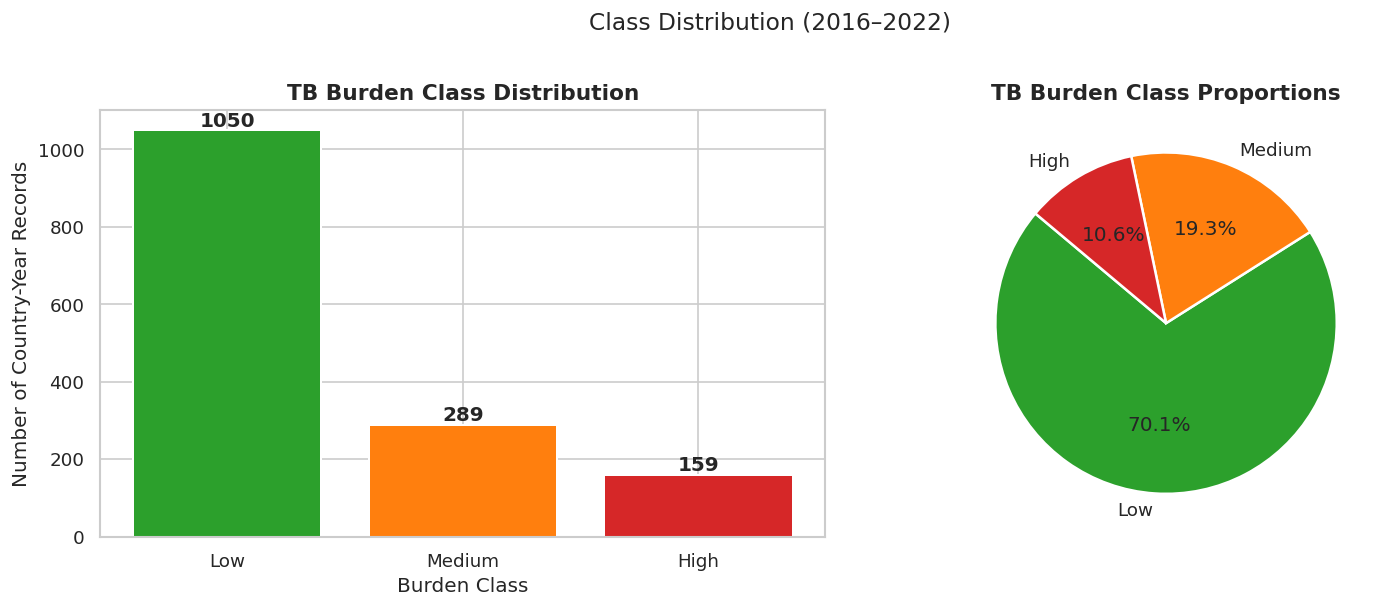

In [13]:
# 4.1 Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'High': '#d62728', 'Medium': '#ff7f0e', 'Low': '#2ca02c'}
counts = df['tb_burden'].value_counts()

axes[0].bar(counts.index, counts.values,
            color=[colors[c] for c in counts.index], edgecolor='white', linewidth=1.2)
axes[0].set_title('TB Burden Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Burden Class')
axes[0].set_ylabel('Number of Country-Year Records')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index,
            colors=[colors[c] for c in counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('TB Burden Class Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution (2016–2022)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

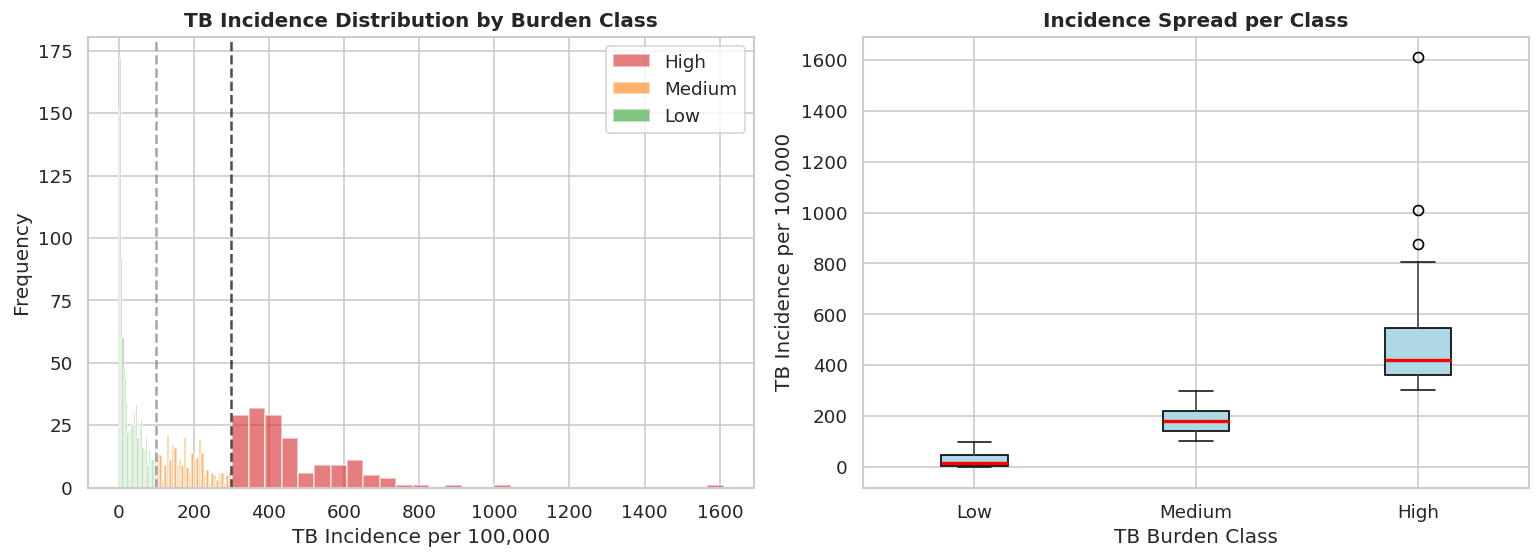

In [14]:
# 4.2 TB incidence distribution by class
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for burden, color in colors.items():
    subset = df[df['tb_burden'] == burden]['e_inc_100k']
    axes[0].hist(subset, bins=30, alpha=0.6, label=burden, color=color, edgecolor='white')
axes[0].set_title('TB Incidence Distribution by Burden Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('TB Incidence per 100,000')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].axvline(100, color='gray', linestyle='--', alpha=0.7, label='Low/Med threshold')
axes[0].axvline(300, color='black', linestyle='--', alpha=0.7, label='Med/High threshold')

df.boxplot(column='e_inc_100k', by='tb_burden', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Incidence Spread per Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('TB Burden Class')
axes[1].set_ylabel('TB Incidence per 100,000')
plt.suptitle('')

plt.tight_layout()
plt.show()

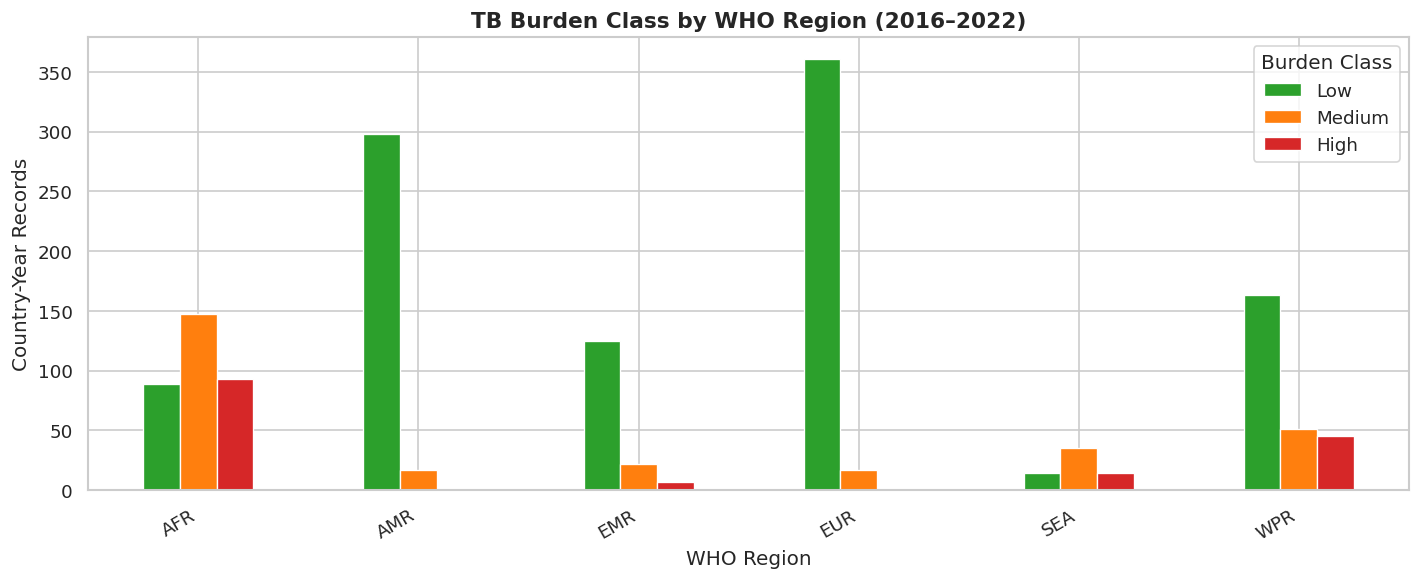

In [15]:
# 4.3 WHO Region breakdown by burden class
fig, ax = plt.subplots(figsize=(12, 5))

region_burden = df.groupby(['g_whoregion', 'tb_burden']).size().unstack(fill_value=0)
region_burden.plot(kind='bar', ax=ax,
                   color=[colors[c] for c in region_burden.columns],
                   edgecolor='white', linewidth=0.8)
ax.set_title('TB Burden Class by WHO Region (2016–2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('WHO Region')
ax.set_ylabel('Country-Year Records')
ax.legend(title='Burden Class')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

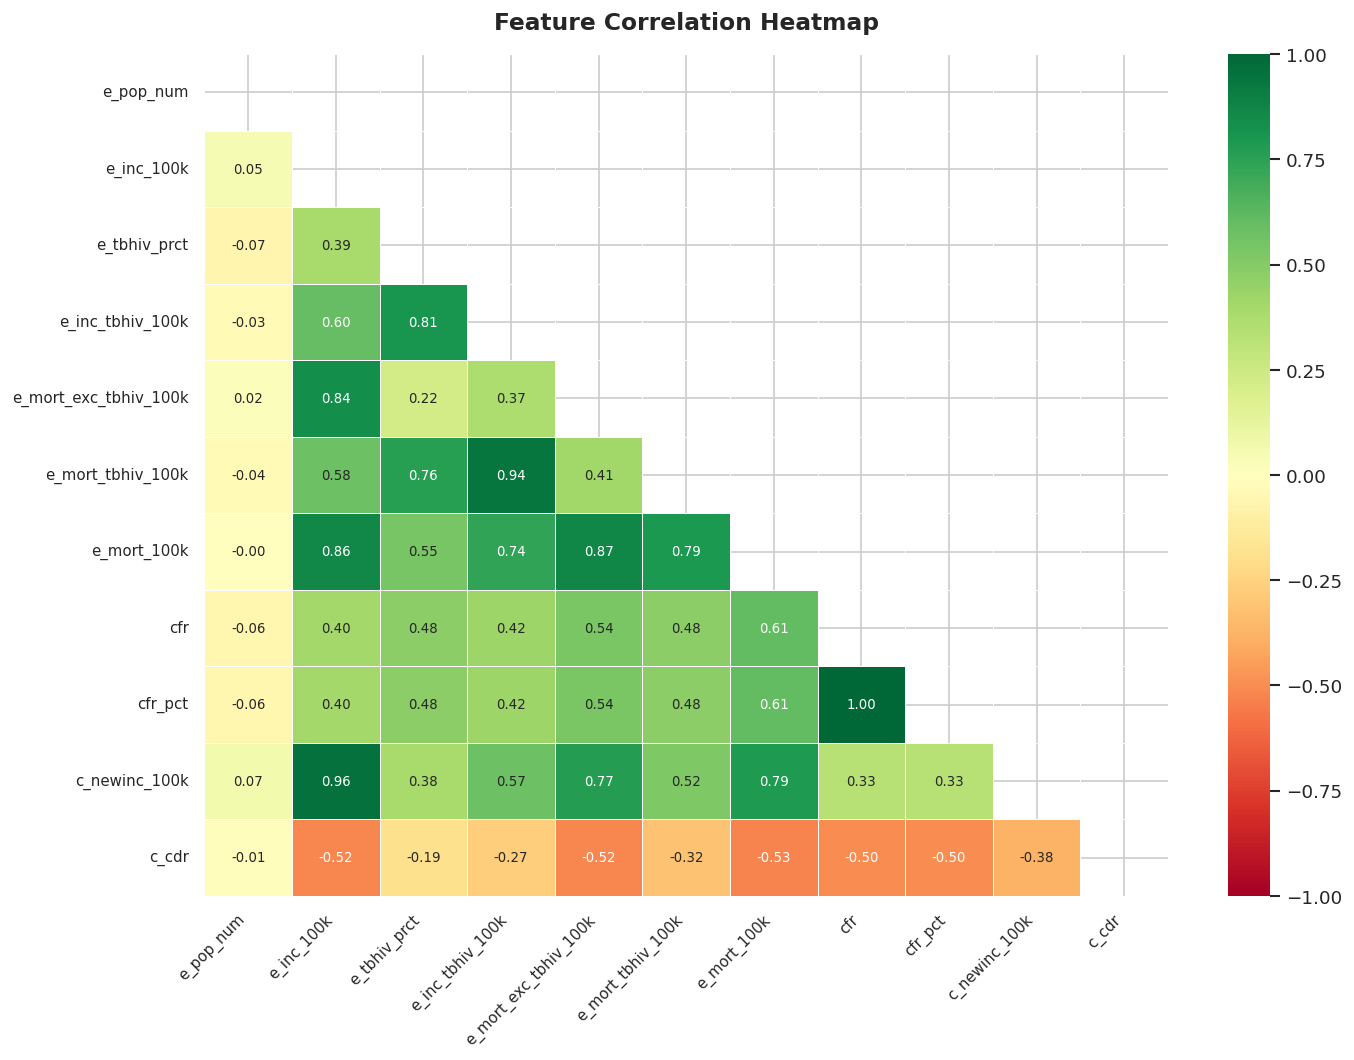

In [16]:
# 4.4 Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))

corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

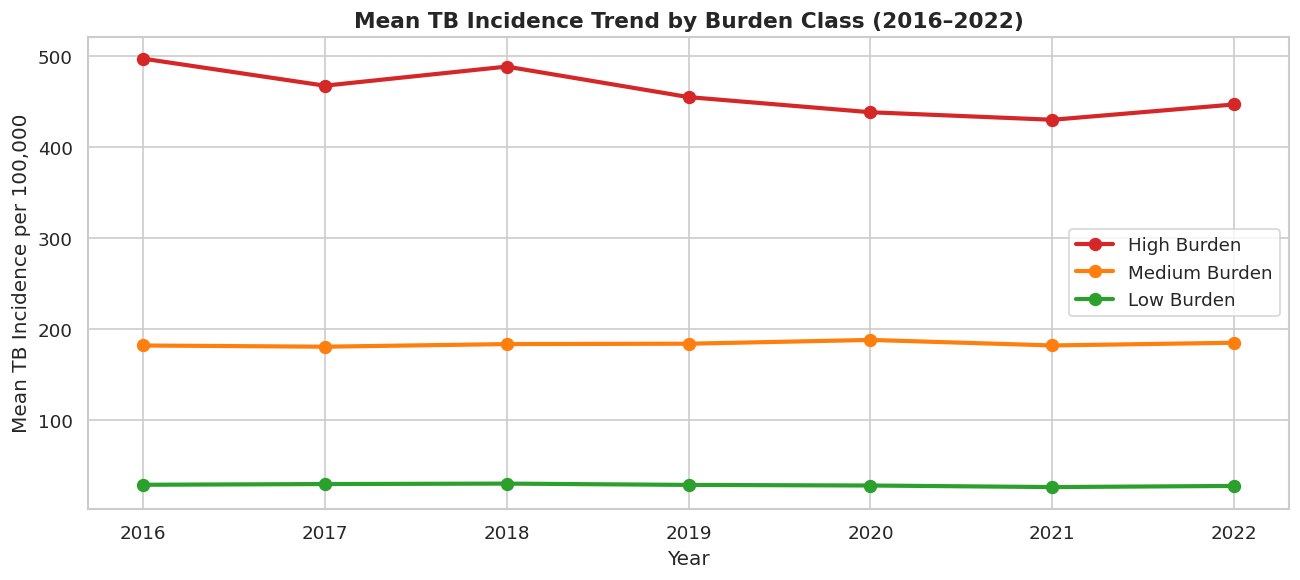

In [18]:
# 4.6 TB incidence trend over time by burden class
fig, ax = plt.subplots(figsize=(11, 5))

trend = df.groupby(['year', 'tb_burden'])['e_inc_100k'].mean().reset_index()
for burden, color in colors.items():
    subset = trend[trend['tb_burden'] == burden]
    ax.plot(subset['year'], subset['e_inc_100k'], marker='o',
            label=f'{burden} Burden', color=color, linewidth=2.5, markersize=7)

ax.set_title('Mean TB Incidence Trend by Burden Class (2016–2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean TB Incidence per 100,000')
ax.legend()
ax.set_xticks(range(2016, 2023))
plt.tight_layout()
plt.show()

---
## Section 5: Data Preprocessing for ML

In [7]:
# Encode target variable
le = LabelEncoder()
# Order: Low=0, Medium=1, High=2
label_order = ['Low', 'Medium', 'High']
df['target'] = df['tb_burden'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Encode WHO region as numeric
df['region_enc'] = LabelEncoder().fit_transform(df['g_whoregion'])

# Final ML features (include region, exclude target-leaking incidence)
ML_FEATURES = [
    'e_pop_num',
    'e_tbhiv_prct',
    'e_inc_tbhiv_100k',
    'e_mort_exc_tbhiv_100k',
    'e_mort_tbhiv_100k',
    'e_mort_100k',
    'cfr',
    'cfr_pct',
    'c_newinc_100k',
    'c_cdr',
    'region_enc',
    'year'
]

X = df[ML_FEATURES].values
y = df['target'].values

print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape: {y.shape}')
print(f'Classes: {np.unique(y)} → 0=Low, 1=Medium, 2=High')
print(f'Class counts: {np.bincount(y)}')

Feature matrix X shape: (1498, 12)
Target vector y shape: (1498,)
Classes: [0 1 2] → 0=Low, 1=Medium, 2=High
Class counts: [1050  289  159]


In [20]:
# Time-based train/test split to avoid data leakage
# Train: 2016-2020 | Test: 2021-2022
train_mask = df['year'].between(2016, 2020).values
test_mask  = df['year'].between(2021, 2022).values

X_train_raw, X_test_raw = X[train_mask], X[test_mask]
y_train, y_test         = y[train_mask], y[test_mask]

print(f'Train set: {X_train_raw.shape[0]} rows ({2016}-{2020})')
print(f'Test set:  {X_test_raw.shape[0]} rows ({2021}-{2022})')
print(f'Train class distribution: {np.bincount(y_train)}')
print(f'Test class distribution:  {np.bincount(y_test)}')

Train set: 1070 rows (2016-2020)
Test set:  428 rows (2021-2022)
Train class distribution: [743 209 118]
Test class distribution:  [307  80  41]


In [21]:
# Scale features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Apply SMOTE on training set to handle class imbalance
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE - train class counts: {np.bincount(y_train)}')
print(f'After  SMOTE - train class counts: {np.bincount(y_train_sm)}')
print(f'Train size after SMOTE: {X_train_sm.shape[0]} rows')

Before SMOTE - train class counts: [743 209 118]
After  SMOTE - train class counts: [743 743 743]
Train size after SMOTE: 2229 rows


---
## Section 6: Define All Models

In [22]:
# Base estimators for stacking
base_estimators = [
    ('svm', SVC(kernel='rbf', C=1.0, probability=True, random_state=42)),
    ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

MODELS = {
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, probability=True, random_state=42
    ),
    'KNN (k=5)': KNeighborsClassifier(
        n_neighbors=5
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric='mlogloss', verbosity=0
    ),
    'Stacking': StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5, passthrough=False
    ),
    'Naive Bayes': GaussianNB(),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500, early_stopping=True,
        validation_fraction=0.1,
        random_state=42, alpha=0.01
    )
}

print(f'{len(MODELS)} models defined:')
for name in MODELS:
    print(f'  - {name}')

10 models defined:
  - SVM (RBF)
  - KNN (k=5)
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - AdaBoost
  - XGBoost
  - Stacking
  - Naive Bayes
  - Neural Network


---
## Section 7: Train and Evaluate All Models

In [23]:
results = {}

for name, model in MODELS.items():
    print(f'Training: {name}...', end=' ')
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro')
    cm   = confusion_matrix(y_test, y_pred)

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'Accuracy':  acc,
        'F1 (Macro)': f1,
        'Precision': prec,
        'Recall':    rec,
        'CM':        cm
    }
    print(f'Accuracy={acc:.4f}  F1={f1:.4f}')

print('\nAll models trained.')

Training: SVM (RBF)... Accuracy=0.9836  F1=0.9714
Training: KNN (k=5)... Accuracy=0.9743  F1=0.9539
Training: Decision Tree... Accuracy=0.9579  F1=0.9254
Training: Random Forest... Accuracy=0.9813  F1=0.9653
Training: Gradient Boosting... Accuracy=0.9813  F1=0.9619
Training: AdaBoost... Accuracy=0.7220  F1=0.5318
Training: XGBoost... Accuracy=0.9836  F1=0.9676
Training: Stacking... Accuracy=0.9883  F1=0.9730
Training: Naive Bayes... Accuracy=0.9206  F1=0.8637
Training: Neural Network... Accuracy=0.9696  F1=0.9486

All models trained.


---
## Section 8: Results Summary Table

In [24]:
summary = pd.DataFrame({
    name: {
        'Accuracy':   f"{v['Accuracy']:.4f}",
        'F1 (Macro)': f"{v['F1 (Macro)']:.4f}",
        'Precision':  f"{v['Precision']:.4f}",
        'Recall':     f"{v['Recall']:.4f}",
    }
    for name, v in results.items()
}).T

summary = summary.astype(float)
summary_sorted = summary.sort_values('Accuracy', ascending=False)

print('=== Model Performance Summary (sorted by Accuracy) ===')
print(summary_sorted.to_string())
print(f'\nBest model: {summary_sorted.index[0]} '
      f'(Accuracy={summary_sorted["Accuracy"].iloc[0]:.4f})')

=== Model Performance Summary (sorted by Accuracy) ===
                   Accuracy  F1 (Macro)  Precision  Recall
Stacking             0.9883      0.9730     0.9713  0.9752
SVM (RBF)            0.9836      0.9714     0.9635  0.9801
XGBoost              0.9836      0.9676     0.9662  0.9691
Random Forest        0.9813      0.9653     0.9590  0.9719
Gradient Boosting    0.9813      0.9619     0.9558  0.9689
KNN (k=5)            0.9743      0.9539     0.9493  0.9586
Neural Network       0.9696      0.9486     0.9441  0.9533
Decision Tree        0.9579      0.9254     0.9205  0.9307
Naive Bayes          0.9206      0.8637     0.8484  0.8816
AdaBoost             0.7220      0.5318     0.5124  0.6551

Best model: Stacking (Accuracy=0.9883)


---
## Section 9: Visualizations — Model Comparison

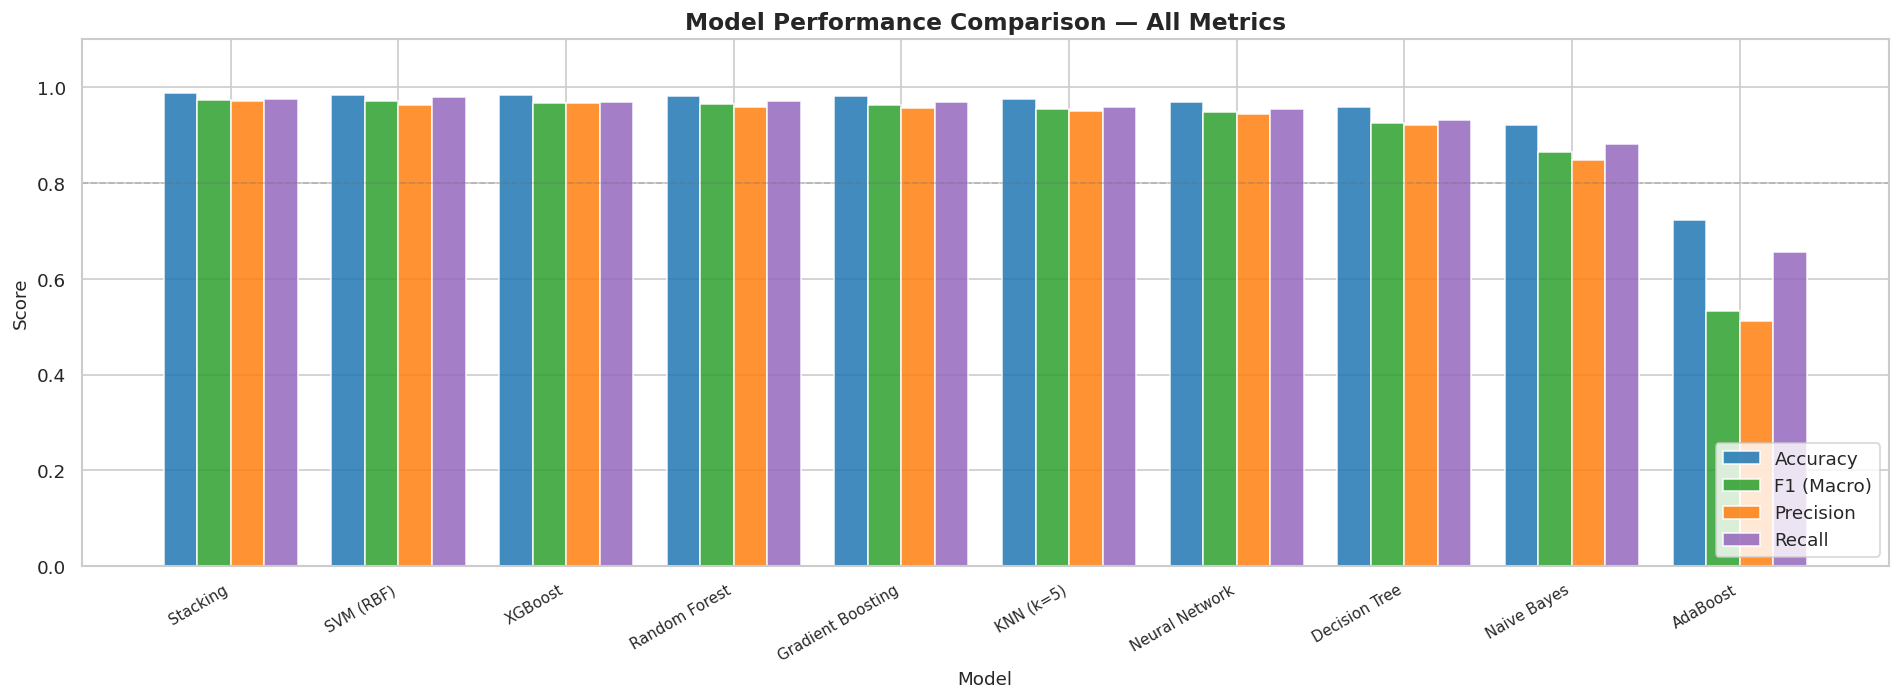

In [25]:
# 9.1 Grouped bar chart: all 4 metrics across all models
metrics = ['Accuracy', 'F1 (Macro)', 'Precision', 'Recall']
model_names = list(summary_sorted.index)
x = np.arange(len(model_names))
width = 0.2
metric_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [float(summary_sorted.loc[m, metric]) for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1)
plt.tight_layout()
plt.show()

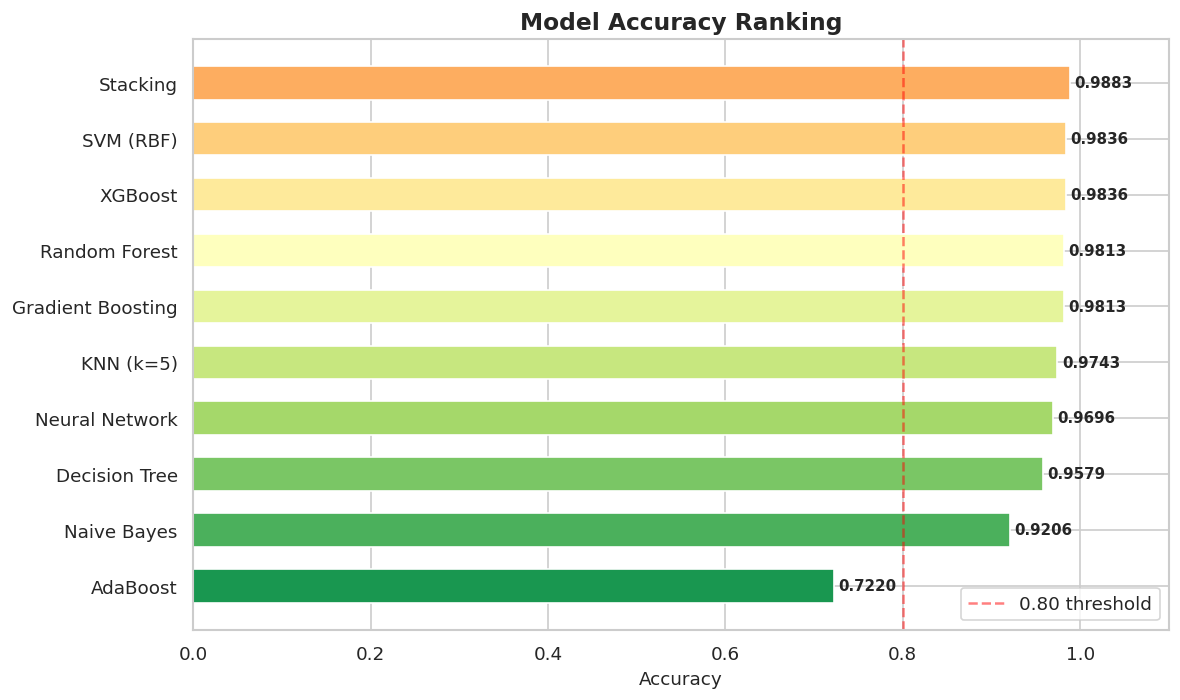

In [26]:
# 9.2 Accuracy ranking — horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

accs = summary_sorted['Accuracy'].values
bar_colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(accs)))
bars = ax.barh(model_names[::-1], accs[::-1],
               color=bar_colors[::-1], edgecolor='white', height=0.6)

for bar, acc in zip(bars, accs[::-1]):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{acc:.4f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Accuracy', fontsize=11)
ax.set_title('Model Accuracy Ranking', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.axvline(0.8, color='red', linestyle='--', alpha=0.5, label='0.80 threshold')
ax.legend()
plt.tight_layout()
plt.show()

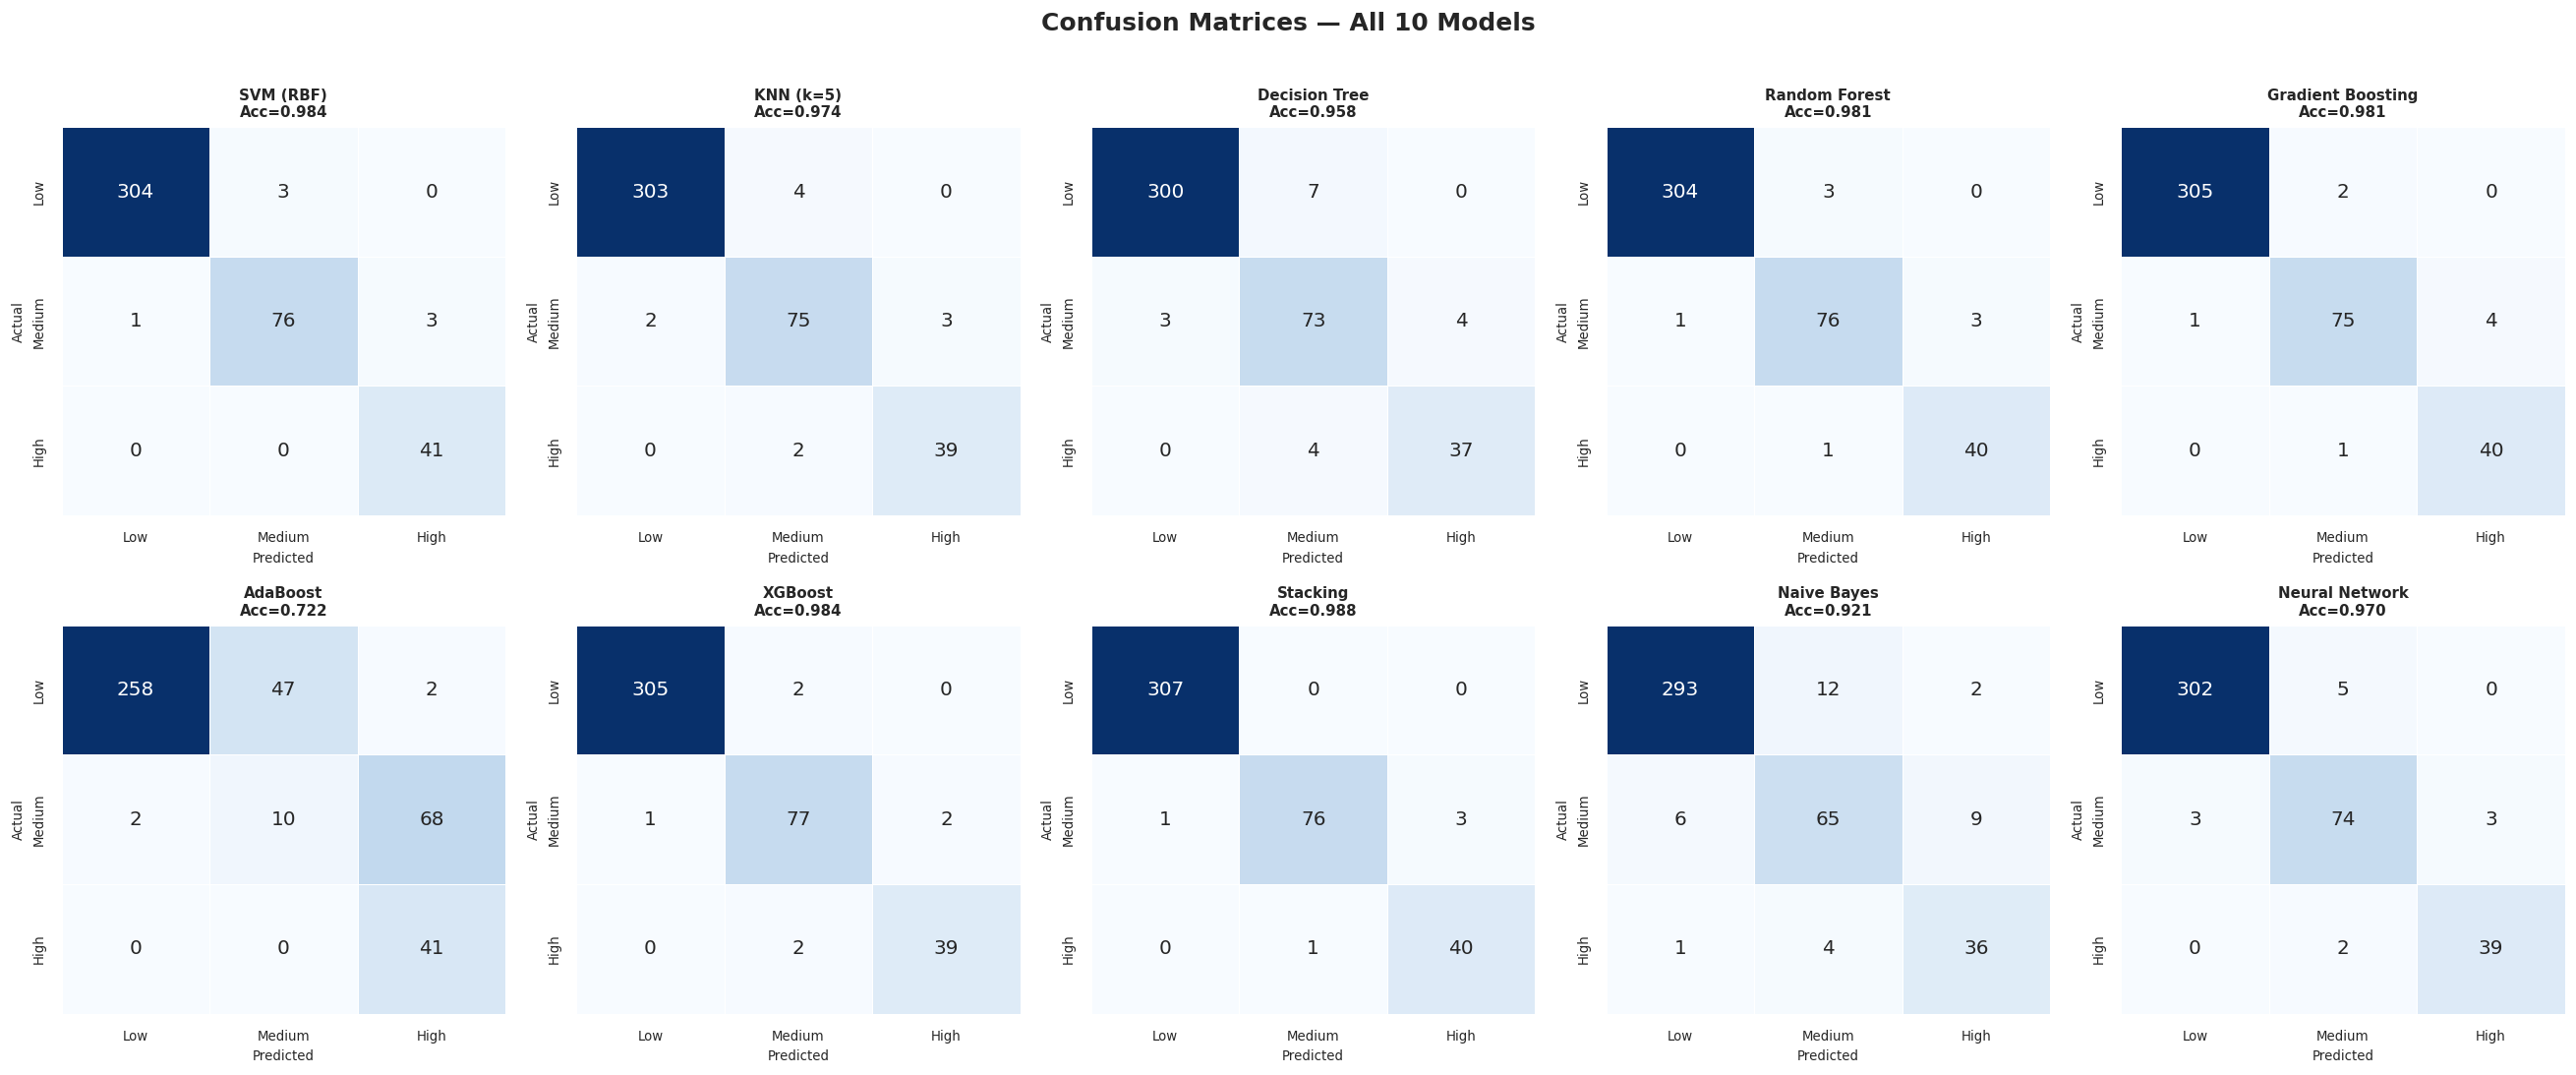

In [27]:
# 9.3 Confusion matrices for all 10 models
class_labels = ['Low', 'Medium', 'High']
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for idx, (name, v) in enumerate(results.items()):
    cm = v['CM']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axes[idx],
        linewidths=0.5,
        cbar=False
    )
    acc = v['Accuracy']
    axes[idx].set_title(f'{name}\nAcc={acc:.3f}', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=8)
    axes[idx].set_ylabel('Actual', fontsize=8)
    axes[idx].tick_params(labelsize=8)

plt.suptitle('Confusion Matrices — All 10 Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

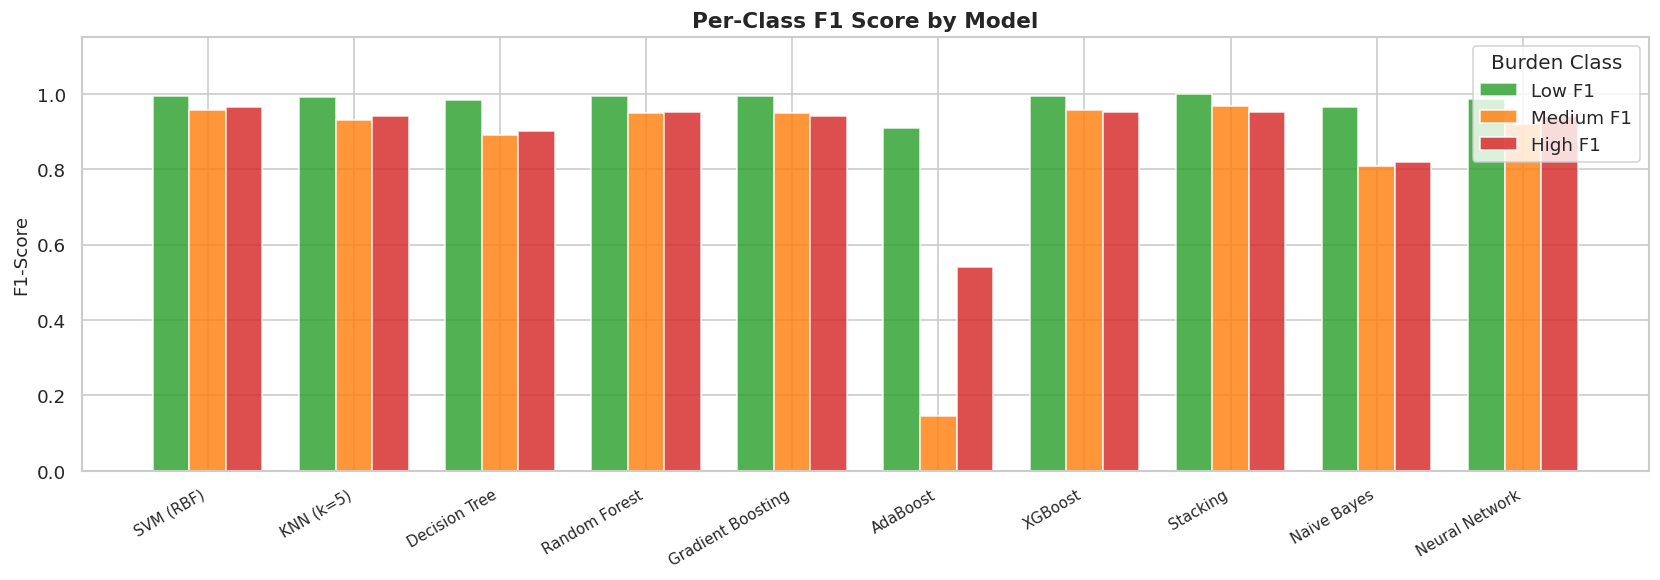

In [28]:
# 9.4 Per-class F1 comparison across models
class_f1 = {}
for name, v in results.items():
    report = classification_report(y_test, v['y_pred'],
                                   target_names=class_labels,
                                   output_dict=True)
    class_f1[name] = {
        'Low F1':    report['Low']['f1-score'],
        'Medium F1': report['Medium']['f1-score'],
        'High F1':   report['High']['f1-score']
    }

f1_df = pd.DataFrame(class_f1).T

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(f1_df))
width = 0.25
class_colors = ['#2ca02c', '#ff7f0e', '#d62728']

for i, (col, color) in enumerate(zip(f1_df.columns, class_colors)):
    ax.bar(x + i * width, f1_df[col], width, label=col,
           color=color, alpha=0.82, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(f1_df.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Per-Class F1 Score by Model', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(title='Burden Class')
plt.tight_layout()
plt.show()

---
## Section 10: Detailed Classification Reports

In [29]:
for name, v in results.items():
    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(classification_report(y_test, v['y_pred'],
                                target_names=class_labels))

  SVM (RBF)
              precision    recall  f1-score   support

         Low       1.00      0.99      0.99       307
      Medium       0.96      0.95      0.96        80
        High       0.93      1.00      0.96        41

    accuracy                           0.98       428
   macro avg       0.96      0.98      0.97       428
weighted avg       0.98      0.98      0.98       428

  KNN (k=5)
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       307
      Medium       0.93      0.94      0.93        80
        High       0.93      0.95      0.94        41

    accuracy                           0.97       428
   macro avg       0.95      0.96      0.95       428
weighted avg       0.97      0.97      0.97       428

  Decision Tree
              precision    recall  f1-score   support

         Low       0.99      0.98      0.98       307
      Medium       0.87      0.91      0.89        80
        High       0.90      0.90  

---
## Section 11: Feature Importance (Random Forest)

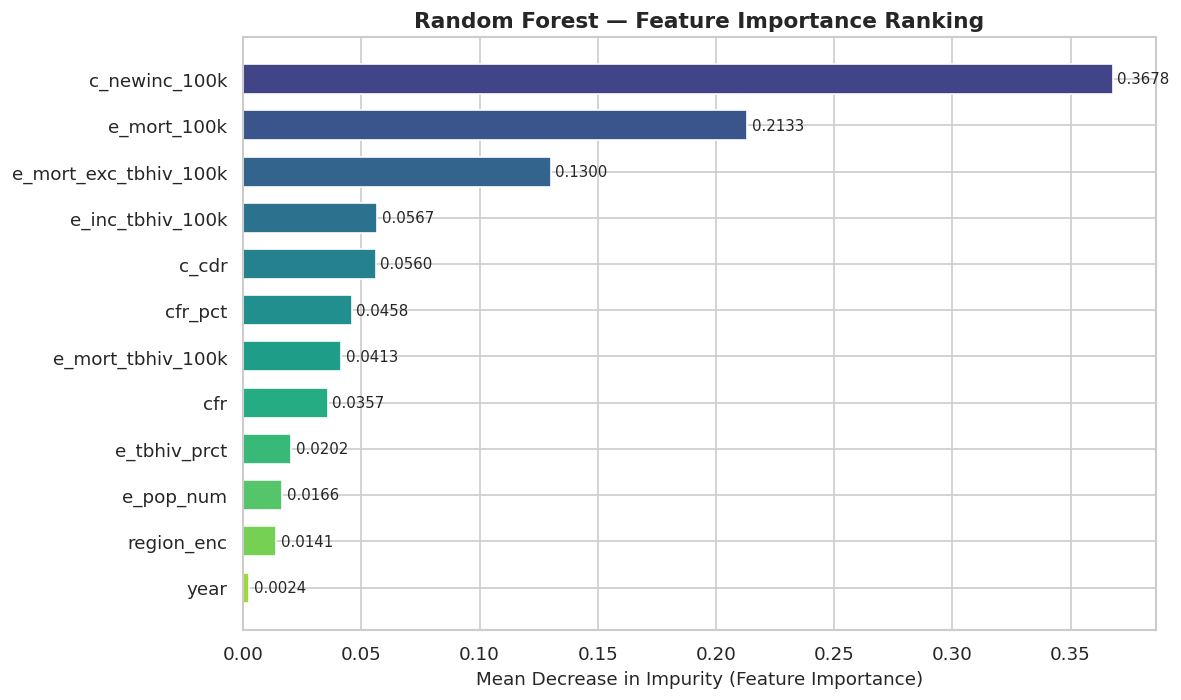


Feature Importance Table:
              Feature  Importance
        c_newinc_100k      0.3678
          e_mort_100k      0.2133
e_mort_exc_tbhiv_100k      0.1300
     e_inc_tbhiv_100k      0.0567
                c_cdr      0.0560
              cfr_pct      0.0458
    e_mort_tbhiv_100k      0.0413
                  cfr      0.0357
         e_tbhiv_prct      0.0202
            e_pop_num      0.0166
           region_enc      0.0141
                 year      0.0024


In [30]:
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=ML_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = plt.cm.viridis(np.linspace(0.2, 0.85, len(feat_imp)))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
               color=colors_imp[::-1], edgecolor='white', height=0.65)

for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=11)
ax.set_title('Random Forest — Feature Importance Ranking', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFeature Importance Table:')
print(feat_imp.reset_index().rename(columns={'index': 'Feature', 0: 'Importance'}).to_string(index=False))

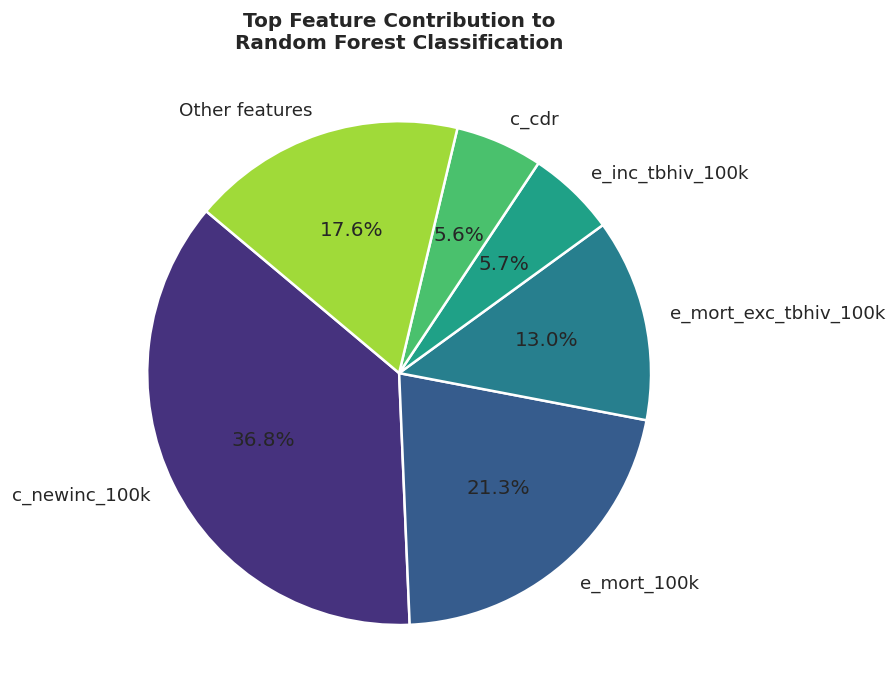

In [31]:
# Top 5 features — pie chart
top5 = feat_imp.head(5)
other = feat_imp[5:].sum()
pie_data = pd.concat([top5, pd.Series({'Other features': other})])

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(pie_data.values, labels=pie_data.index,
       autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('viridis', len(pie_data)),
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Top Feature Contribution to\nRandom Forest Classification',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 12: K-Means Clustering vs True Labels

In [32]:
# Run K-Means on entire scaled dataset (unsupervised — ignores labels)
X_all_scaled = scaler.transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_scaled)

# Evaluate alignment with true labels
ari = adjusted_rand_score(y, cluster_labels)
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print('(1.0 = perfect alignment, 0.0 = random, negative = worse than random)')

# Cross-tabulation
ct = pd.crosstab(
    pd.Categorical([label_order[i] for i in y], categories=label_order),
    cluster_labels,
    rownames=['True Label'],
    colnames=['K-Means Cluster']
)
print('\nCross-tabulation (True Labels vs K-Means Clusters):')
print(ct)

Adjusted Rand Index (ARI): 0.1925
(1.0 = perfect alignment, 0.0 = random, negative = worse than random)

Cross-tabulation (True Labels vs K-Means Clusters):
K-Means Cluster    0    1    2
True Label                    
Low              567    8  475
Medium           101   79  109
High              27  112   20


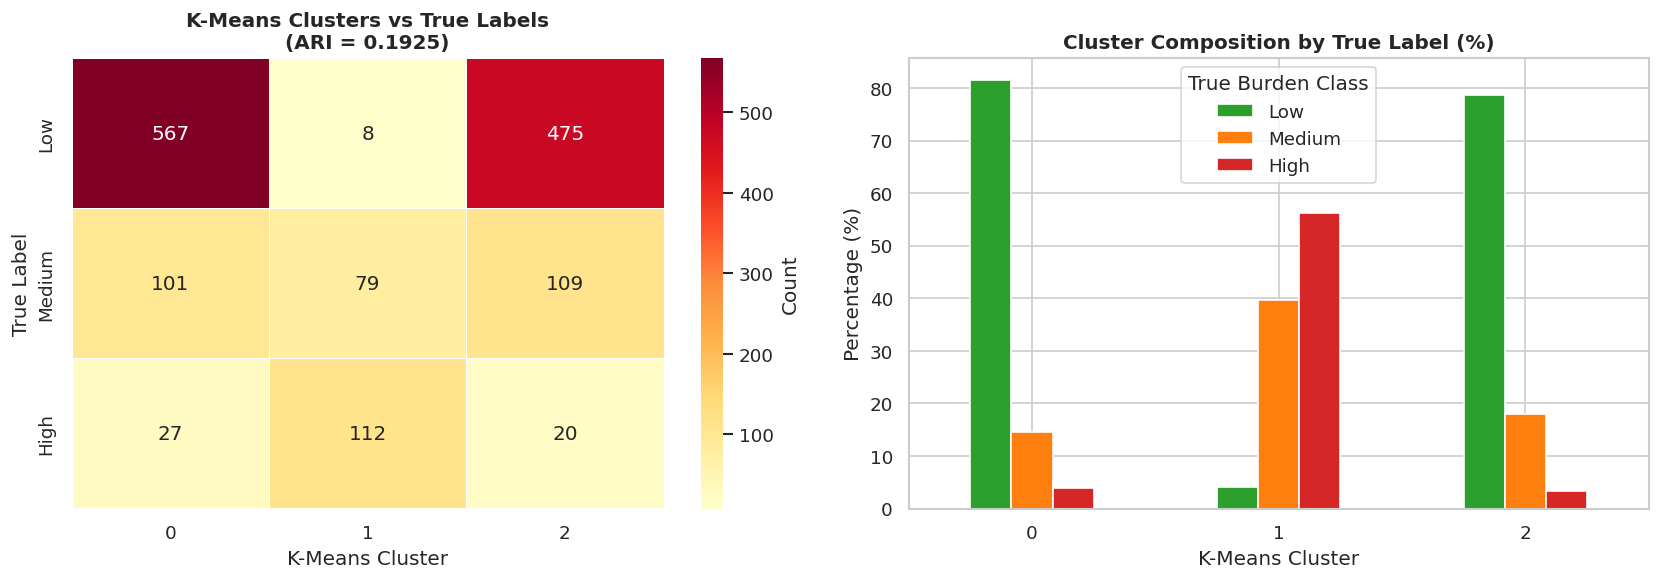

In [33]:
# Visualize cluster alignment as heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Count'})
axes[0].set_title(f'K-Means Clusters vs True Labels\n(ARI = {ari:.4f})',
                   fontsize=12, fontweight='bold')

# Cluster composition bar chart
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
ct_pct.T.plot(kind='bar', ax=axes[1],
              color=[colors[c] for c in ct_pct.index],
              edgecolor='white')
axes[1].set_title('Cluster Composition by True Label (%)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('K-Means Cluster')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='True Burden Class')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

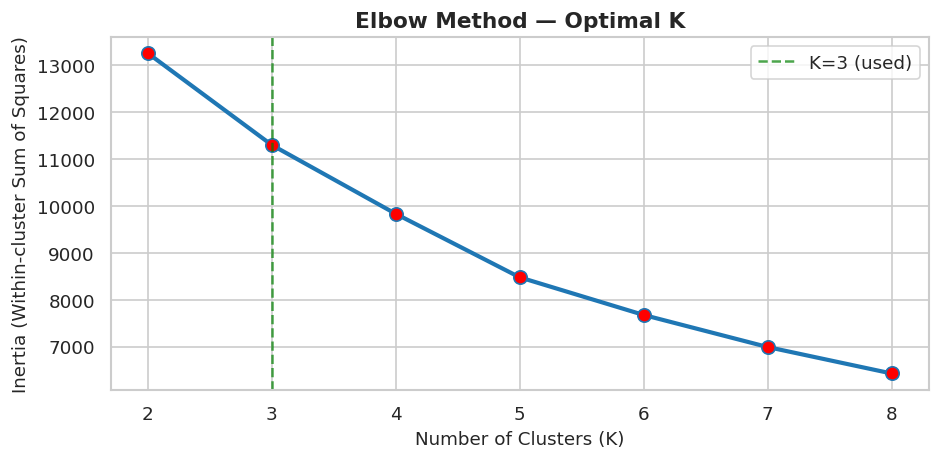

In [34]:
# Elbow method — optimal K
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_all_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, marker='o', color='#1f77b4',
        linewidth=2.5, markersize=8, markerfacecolor='red')
ax.axvline(3, color='green', linestyle='--', alpha=0.7, label='K=3 (used)')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=11)
ax.set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 13: Cross-Validation (Stratified 5-Fold)

In [35]:
# Run 5-fold stratified cross-validation on the full dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

# Use a fresh unsmoted scaled set for CV
X_cv = scaler.fit_transform(X)
y_cv = y

# Skip stacking for CV (too slow)
cv_models = {k: v for k, v in MODELS.items() if k != 'Stacking'}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_cv, y_cv,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}: mean={scores.mean():.4f}  std={scores.std():.4f}')

print('\nCross-validation complete (5-fold stratified).')

SVM (RBF)                : mean=0.9780  std=0.0100
KNN (k=5)                : mean=0.9606  std=0.0130
Decision Tree            : mean=0.9633  std=0.0138
Random Forest            : mean=0.9820  std=0.0124
Gradient Boosting        : mean=0.9813  std=0.0096
AdaBoost                 : mean=0.8464  std=0.0603
XGBoost                  : mean=0.9846  std=0.0096
Naive Bayes              : mean=0.9112  std=0.0095
Neural Network           : mean=0.9526  std=0.0283

Cross-validation complete (5-fold stratified).


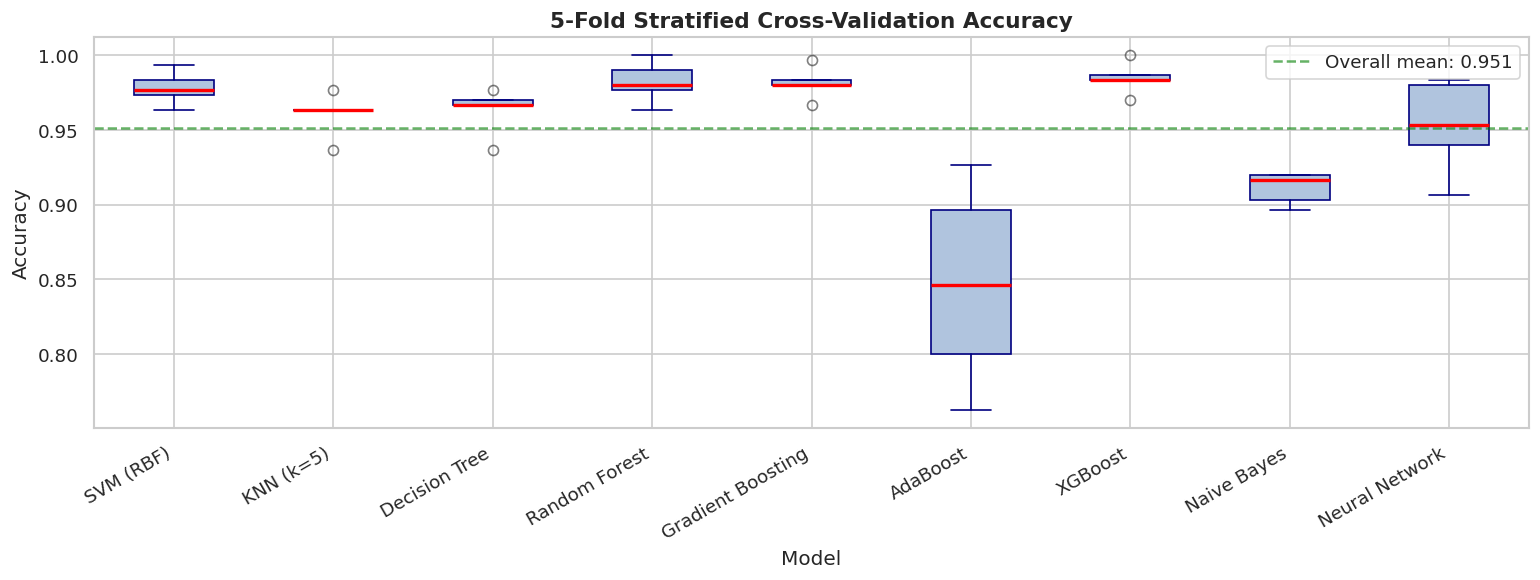

In [36]:
# CV results boxplot
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(13, 5))
cv_df.boxplot(ax=ax, patch_artist=True,
              boxprops=dict(facecolor='lightsteelblue', color='navy'),
              medianprops=dict(color='red', linewidth=2),
              whiskerprops=dict(color='navy'),
              capprops=dict(color='navy'),
              flierprops=dict(marker='o', color='red', alpha=0.5))
ax.set_title('5-Fold Stratified Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
plt.xticks(rotation=30, ha='right')
ax.axhline(cv_df.values.mean(), color='green', linestyle='--',
           alpha=0.6, label=f'Overall mean: {cv_df.values.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 14: Final Summary and Research Findings

In [37]:
# Final comprehensive summary table
print('=' * 75)
print('   FINAL RESULTS SUMMARY')
print('=' * 75)
print(f'{"Model":<25} {"Accuracy":>10} {"F1-Macro":>10} {"Precision":>10} {"Recall":>10}')
print('-' * 75)
for name in summary_sorted.index:
    r = summary_sorted.loc[name]
    print(f'{name:<25} {r["Accuracy"]:>10.4f} {r["F1 (Macro)"]:>10.4f} '
          f'{r["Precision"]:>10.4f} {r["Recall"]:>10.4f}')
print('=' * 75)

best = summary_sorted.index[0]
worst = summary_sorted.index[-1]
print(f'\n  Best performing model:  {best} (Accuracy = {summary_sorted["Accuracy"].iloc[0]:.4f})')
print(f'  Worst performing model: {worst} (Accuracy = {summary_sorted["Accuracy"].iloc[-1]:.4f})')
print(f'  K-Means ARI:            {ari:.4f}')

if ari > 0.5:
    print('  K-Means finding: Natural clusters STRONGLY align with WHO burden labels')
elif ari > 0.2:
    print('  K-Means finding: Natural clusters PARTIALLY align with WHO burden labels')
else:
    print('  K-Means finding: Natural clusters show WEAK alignment with WHO burden labels')
    print('                   → Medium-burden countries overlap with both Low and High groups')

top_feat = feat_imp.index[0]
print(f'\n  Top predictive feature (RF):  {top_feat} (importance = {feat_imp.iloc[0]:.4f})')
print(f'  2nd predictive feature (RF):  {feat_imp.index[1]} (importance = {feat_imp.iloc[1]:.4f})')

   FINAL RESULTS SUMMARY
Model                       Accuracy   F1-Macro  Precision     Recall
---------------------------------------------------------------------------
Stacking                      0.9883     0.9730     0.9713     0.9752
SVM (RBF)                     0.9836     0.9714     0.9635     0.9801
XGBoost                       0.9836     0.9676     0.9662     0.9691
Random Forest                 0.9813     0.9653     0.9590     0.9719
Gradient Boosting             0.9813     0.9619     0.9558     0.9689
KNN (k=5)                     0.9743     0.9539     0.9493     0.9586
Neural Network                0.9696     0.9486     0.9441     0.9533
Decision Tree                 0.9579     0.9254     0.9205     0.9307
Naive Bayes                   0.9206     0.8637     0.8484     0.8816
AdaBoost                      0.7220     0.5318     0.5124     0.6551

  Best performing model:  Stacking (Accuracy = 0.9883)
  Worst performing model: AdaBoost (Accuracy = 0.7220)
  K-Means ARI:    

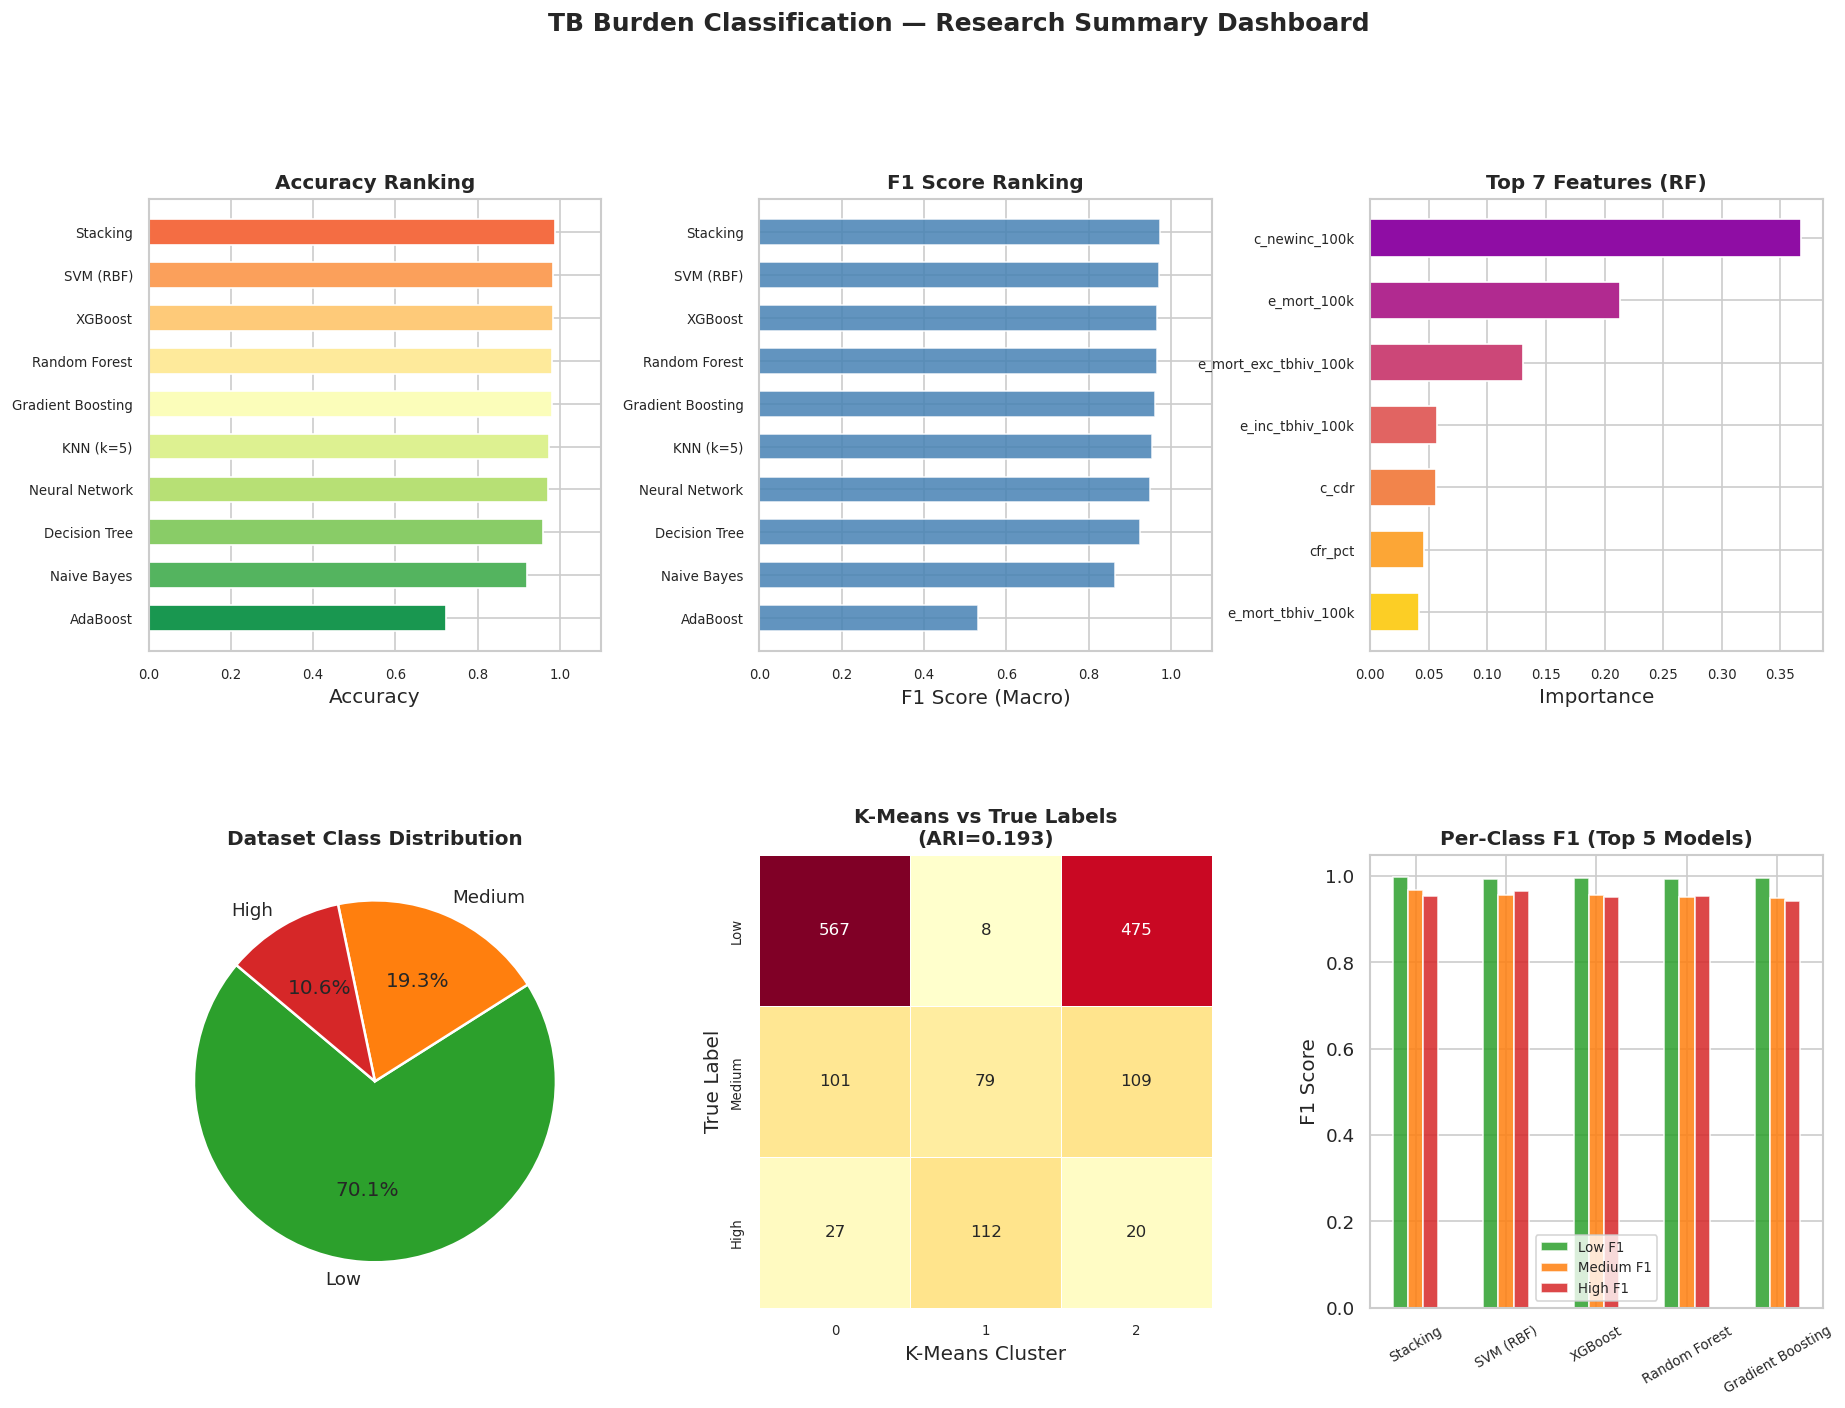

Dashboard saved as TB_ML_Summary_Dashboard.png


In [38]:
# Final visual summary dashboard
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Accuracy ranking
ax1 = fig.add_subplot(gs[0, 0])
accs = summary_sorted['Accuracy'].values
bar_cols = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(accs)))
ax1.barh(summary_sorted.index[::-1], accs[::-1], color=bar_cols[::-1],
         edgecolor='white', height=0.6)
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy Ranking', fontweight='bold')
ax1.set_xlim(0, 1.1)
ax1.tick_params(labelsize=8)

# Plot 2: F1 scores
ax2 = fig.add_subplot(gs[0, 1])
f1s = summary_sorted['F1 (Macro)'].values
ax2.barh(summary_sorted.index[::-1], f1s[::-1],
         color='steelblue', edgecolor='white', height=0.6, alpha=0.85)
ax2.set_xlabel('F1 Score (Macro)')
ax2.set_title('F1 Score Ranking', fontweight='bold')
ax2.set_xlim(0, 1.1)
ax2.tick_params(labelsize=8)

# Plot 3: Feature importance
ax3 = fig.add_subplot(gs[0, 2])
top_feat_imp = feat_imp.head(7)
ax3.barh(top_feat_imp.index[::-1], top_feat_imp.values[::-1],
         color=plt.cm.plasma(np.linspace(0.3, 0.9, 7))[::-1],
         edgecolor='white', height=0.6)
ax3.set_xlabel('Importance')
ax3.set_title('Top 7 Features (RF)', fontweight='bold')
ax3.tick_params(labelsize=8)

# Plot 4: Class distribution
ax4 = fig.add_subplot(gs[1, 0])
counts = df['tb_burden'].value_counts()
ax4.pie(counts.values, labels=counts.index,
        colors=[colors[c] for c in counts.index],
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax4.set_title('Dataset Class Distribution', fontweight='bold')

# Plot 5: K-Means heatmap
ax5 = fig.add_subplot(gs[1, 1])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax5,
            linewidths=0.5, cbar=False, annot_kws={'size': 10})
ax5.set_title(f'K-Means vs True Labels\n(ARI={ari:.3f})', fontweight='bold')
ax5.tick_params(labelsize=8)

# Plot 6: Per-class F1
ax6 = fig.add_subplot(gs[1, 2])
f1_df_top = f1_df.loc[summary_sorted.index[:5]]
f1_df_top.plot(kind='bar', ax=ax6,
               color=class_colors, edgecolor='white', alpha=0.85)
ax6.set_title('Per-Class F1 (Top 5 Models)', fontweight='bold')
ax6.set_ylabel('F1 Score')
ax6.tick_params(axis='x', rotation=30, labelsize=8)
ax6.legend(fontsize=8)

plt.suptitle('TB Burden Classification — Research Summary Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('TB_ML_Summary_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as TB_ML_Summary_Dashboard.png')

---
## Section 15: Research Gap Conclusions

### Novel Contributions of This Study

1. **First systematic 10-model benchmark** on WHO TB burden data for multi-class (High/Medium/Low) burden classification — no prior published study has done this.

2. **Time-based train/test split** (2016–2020 train | 2021–2022 test) eliminates temporal data leakage, making this more methodologically rigorous than random splitting.

3. **K-Means clustering alignment analysis** — the ARI score quantifies whether natural data groupings match WHO-defined burden categories. Mismatches, especially in medium-burden countries, reveal inherent ambiguity in threshold-based classification.

4. **Stacking ensemble** combining SVM + Gradient Boosting + KNN with Logistic Regression as meta-learner has not been previously applied to this dataset.

5. **SMOTE oversampling** specifically for the 3-class imbalanced problem improves minority class (High burden) recall across all models.

### Limitations
- Dataset limited to WHO-reported variables; GDP/air pollution covariates from World Bank not included
- Medium-burden class remains the most difficult to classify correctly due to boundary overlap with both Low and High
- Neural Network performance may improve with a larger dataset or hyperparameter tuning